In [1]:
import os
import time
import shutil
import pathlib
import itertools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
import warnings
warnings.filterwarnings("ignore")

print('modules loaded')


modules loaded


In [ ]:
def define_paths(data_dir):  
    filepaths = []
    labels = []

    if not os.path.exists(data_dir):
        print(f'Warning: Directory {data_dir} does not exist.')
        return [], []

    folds = [f for f in os.listdir(data_dir) if not f.startswith('.')]
    for fold in folds:
        foldpath = os.path.join(data_dir, fold)
        
        if not os.path.isdir(foldpath):
            continue

        filelist = [f for f in os.listdir(foldpath) if not f.startswith('.')]

        for fold_ in filelist:
            foldpath_ = os.path.join(foldpath, fold_)
            
            if not os.path.isdir(foldpath_):
                continue

            filelist_ = [f for f in os.listdir(foldpath_) if not f.startswith('.')]

            for file_ in filelist_:
                fpath = os.path.join(foldpath_, file_)
                filepaths.append(fpath)
                labels.append(fold_)

    return filepaths, labels


def define_df(files, classes):
    Fseries = pd.Series(files, name= 'filepaths')
    Lseries = pd.Series(classes, name='labels')
    # Ensure we don't have empty dataframes
    if len(files) == 0:
         return pd.DataFrame(columns=['filepaths', 'labels'])
    return pd.concat([Fseries, Lseries], axis= 1)


def create_df(data_dir):

    files, classes = define_paths(data_dir)
    df = define_df(files, classes)
    
    if df.empty:
        print('No files found. Please check data directory.')
        return df, df, df

    strat = df['labels']
    train_df, dummy_df = train_test_split(df, train_size=0.7, shuffle=True, random_state=123, stratify=strat)

    strat = dummy_df['labels']
    valid_df, test_df= train_test_split(dummy_df, train_size=0.5, shuffle=True, random_state=123, stratify=strat)

    return train_df, valid_df, test_df

In [3]:
def create_model_data (train_df, valid_df, test_df, batch_size):

    img_size = (224, 224)
    channels = 3
    color = 'rgb'

    ts_length = len(test_df)
    test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))

    tr_gen = ImageDataGenerator(preprocessing_function=densenet_preprocess, horizontal_flip=True)
    ts_gen = ImageDataGenerator(preprocessing_function=densenet_preprocess)

    train_gen = tr_gen.flow_from_dataframe(train_df, x_col='filepaths', y_col='labels', target_size=img_size, class_mode='categorical',
                                        color_mode=color, shuffle=True, batch_size=batch_size)

    valid_gen = ts_gen.flow_from_dataframe(valid_df, x_col='filepaths', y_col='labels', target_size=img_size, class_mode='categorical',
                                        color_mode=color, shuffle=True, batch_size=batch_size)

    test_gen = ts_gen.flow_from_dataframe(test_df, x_col='filepaths', y_col='labels', target_size=img_size, class_mode='categorical',
                                        color_mode=color, shuffle=False, batch_size=test_batch_size)

    return train_gen, valid_gen, test_gen


In [4]:
def show_images(gen):


    g_dict = gen.class_indices
    classes = list(g_dict.keys())
    images, labels = next(gen)

    length = len(labels)
    sample = min(length, 25)

    plt.figure(figsize= (20, 20))

    for i in range(sample):
        plt.subplot(5, 5, i + 1)
        image = images[i] / 255
        plt.imshow(image)
        index = np.argmax(labels[i])
        class_name = classes[index]
        plt.title(class_name, color= 'blue', fontsize= 12)
        plt.axis('off')
    plt.show()

In [5]:
def plot_label_count(df, plot_title):

    vcounts = df['labels'].value_counts()
    labels = vcounts.keys().tolist()
    values = vcounts.tolist()
    lcount = len(labels)

    if lcount > 55:
        print('The number of labels is > 55, no plot will be produced')

    else:
        plot_labels(lcount, labels, values, plot_title)

def plot_labels(lcount, labels, values, plot_title):
    width = lcount * 4
    width = np.min([width, 20])

    plt.figure(figsize= (width, 5))

    form = {'family': 'serif', 'color': 'blue', 'size': 25}
    sns.barplot(labels, values)
    plt.title(f'Images per Label in {plot_title} data', fontsize= 24, color= 'blue')
    plt.xticks(rotation= 90, fontsize= 18)
    plt.yticks(fontsize= 18)
    plt.xlabel('CLASS', fontdict= form)
    yaxis_label = 'IMAGE COUNT'
    plt.ylabel(yaxis_label, fontdict= form)

    rotation = 'vertical' if lcount >= 8 else 'horizontal'
    for i in range(lcount):
        plt.text(i, values[i] / 2, str(values[i]), fontsize= 12,
                rotation= rotation, color= 'yellow', ha= 'center')

    plt.show()

In [6]:
class MyCallback(keras.callbacks.Callback):
    def __init__(self, patience, stop_patience, threshold, factor, batches, epochs, ask_epoch):
        super(MyCallback, self).__init__()
        self.patience = patience
        self.stop_patience = stop_patience
        self.threshold = threshold
        self.factor = factor
        self.batches = batches
        self.epochs = epochs
        self.ask_epoch = ask_epoch
        self.ask_epoch_initial = ask_epoch

        self.count = 0
        self.stop_count = 0
        self.best_epoch = 1
        self.highest_tracc = 0.0
        self.lowest_vloss = np.inf

    def _get_current_lr(self):
        lr_attr = getattr(self.model.optimizer, 'learning_rate', None)
        if lr_attr is None:
            lr_attr = getattr(self.model.optimizer, 'lr', None)
        if lr_attr is None:
            return 0.0
        try:
            return float(tf.keras.backend.get_value(lr_attr))
        except Exception:
            return float(lr_attr)

    def _set_current_lr(self, new_lr):
        lr_attr = getattr(self.model.optimizer, 'learning_rate', None)
        if lr_attr is None:
            lr_attr = getattr(self.model.optimizer, 'lr', None)
        if lr_attr is None:
            return
        try:
            if hasattr(lr_attr, 'assign'):
                lr_attr.assign(new_lr)
            else:
                tf.keras.backend.set_value(lr_attr, new_lr)
        except Exception:
            if hasattr(self.model.optimizer, 'learning_rate'):
                self.model.optimizer.learning_rate = new_lr
            elif hasattr(self.model.optimizer, 'lr'):
                self.model.optimizer.lr = new_lr

    def on_train_begin(self, logs=None):
        self.initial_lr = self._get_current_lr()
        self.best_weights = self.model.get_weights()
        self.initial_weights = self.model.get_weights()

        msg = 'Do you want model asks you to halt the training [y/n] ?'
        print(msg)
        try:
            ans = input('')
        except Exception:
            ans = 'n'

        if ans in ['Y', 'y']:
            self.ask_permission = 1
        else:
            self.ask_permission = 0

        msg = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format(
            'Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor', '% Improv', 'Duration'
        )
        print(msg)
        self.start_time = time.time()

    def on_train_end(self, logs=None):
        stop_time = time.time()
        tr_duration = stop_time - self.start_time
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))

        msg = f'training elapsed time was {str(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds'
        print(msg)

        self.model.set_weights(self.best_weights)

    def on_train_batch_end(self, batch, logs=None):
        acc = logs.get('accuracy') * 100
        loss = logs.get('loss')
        msg = '{0:20s}processing batch {1:} of {2:5s}-   accuracy=  {3:5.3f}   -   loss: {4:8.5f}'.format(
            ' ', str(batch), str(self.batches), acc, loss
        )
        print(msg, end='\r')

    def on_epoch_begin(self, epoch, logs=None):
        self.ep_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        ep_end = time.time()
        duration = ep_end - self.ep_start

        current_lr = self._get_current_lr()
        lr = current_lr
        acc = logs.get('accuracy')
        v_acc = logs.get('val_accuracy')
        loss = logs.get('loss')
        v_loss = logs.get('val_loss')

        if acc < self.threshold:
            monitor = 'accuracy'
            if epoch == 0 or self.highest_tracc == 0:
                pimprov = 0.0
            else:
                pimprov = (acc - self.highest_tracc) * 100 / self.highest_tracc

            if acc > self.highest_tracc:
                self.highest_tracc = acc
                self.best_weights = self.model.get_weights()
                self.count = 0
                self.stop_count = 0
                if v_loss < self.lowest_vloss:
                    self.lowest_vloss = v_loss
                self.best_epoch = epoch + 1
            else:
                if self.count >= self.patience - 1:
                    lr = lr * self.factor
                    self._set_current_lr(lr)
                    self.count = 0
                    self.stop_count = self.stop_count + 1
                    if v_loss < self.lowest_vloss:
                        self.lowest_vloss = v_loss
                else:
                    self.count = self.count + 1
        else:
            monitor = 'val_loss'
            if epoch == 0 or self.lowest_vloss == np.inf:
                pimprov = 0.0
            else:
                pimprov = (self.lowest_vloss - v_loss) * 100 / self.lowest_vloss

            if v_loss < self.lowest_vloss:
                self.lowest_vloss = v_loss
                self.best_weights = self.model.get_weights()
                self.count = 0
                self.stop_count = 0
                self.best_epoch = epoch + 1
            else:
                if self.count >= self.patience - 1:
                    lr = lr * self.factor
                    self.stop_count = self.stop_count + 1
                    self.count = 0
                    self._set_current_lr(lr)
                else:
                    self.count = self.count + 1

                if acc > self.highest_tracc:
                    self.highest_tracc = acc

        msg = f'{str(epoch + 1):^3s}/{str(self.epochs):4s} {loss:^9.3f}{acc * 100:^9.3f}{v_loss:^9.5f}{v_acc * 100:^9.3f}{current_lr:^9.5f}{lr:^9.5f}{monitor:^11s}{pimprov:^10.2f}{duration:^8.2f}'
        print(msg)

        if self.stop_count > self.stop_patience - 1:
            msg = f'training has been halted at epoch {epoch + 1} after {self.stop_patience} adjustments of learning rate with no improvement'
            print(msg)
            self.model.stop_training = True



In [7]:
def plot_training(hist):

    tr_acc = hist.history['accuracy']
    tr_loss = hist.history['loss']
    val_acc = hist.history['val_accuracy']
    val_loss = hist.history['val_loss']
    index_loss = np.argmin(val_loss)
    val_lowest = val_loss[index_loss]
    index_acc = np.argmax(val_acc)
    acc_highest = val_acc[index_acc]
    Epochs = [i+1 for i in range(len(tr_acc))]
    loss_label = f'best epoch= {str(index_loss + 1)}'
    acc_label = f'best epoch= {str(index_acc + 1)}'

    plt.figure(figsize= (20, 8))
    plt.style.use('fivethirtyeight')

    plt.subplot(1, 2, 1)
    plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
    plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
    plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
    plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
    plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout
    plt.show()

In [8]:
def plot_confusion_matrix(cm, classes, normalize= False, title= 'Confusion Matrix', cmap= plt.cm.Blues):

	plt.figure(figsize= (10, 10))
	plt.imshow(cm, interpolation= 'nearest', cmap= cmap)
	plt.title(title)
	plt.colorbar()

	tick_marks = np.arange(len(classes))
	plt.xticks(tick_marks, classes, rotation= 45)
	plt.yticks(tick_marks, classes)

	if normalize:
		cm = cm.astype('float') / cm.sum(axis= 1)[:, np.newaxis]
		print('Normalized Confusion Matrix')

	else:
		print('Confusion Matrix, Without Normalization')

	print(cm)

	thresh = cm.max() / 2.
	for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
		plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

	plt.tight_layout()
	plt.ylabel('True Label')
	plt.xlabel('Predicted Label')

In [ ]:
data_dir = '/Users/vermaryan1/Desktop/CODING/PYTHON/CNN-Leukemia-Detection-EfficientNetB3-/C-NMC_Leukemia/training_data'

try:
    train_df, valid_df, test_df = create_df(data_dir)
    batch_size = 40
    if not train_df.empty:
        train_gen, valid_gen, test_gen = create_model_data(train_df, valid_df, test_df, batch_size)
    else:
        print('Skipping model data creation due to empty dataframes')
except Exception as e:
    print(f'An error occurred: {e}')
    import traceback
    traceback.print_exc()


Found 7461 validated image filenames belonging to 2 classes.
Found 1599 validated image filenames belonging to 2 classes.
Found 1600 validated image filenames belonging to 2 classes.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.008305506..0.00051057315].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.008305506..0.0007839722].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.008305506..0.0007839722].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.008305506..0.0007156225].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.008305506..0.00037387357].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.008305506..0.00010047448].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] fo

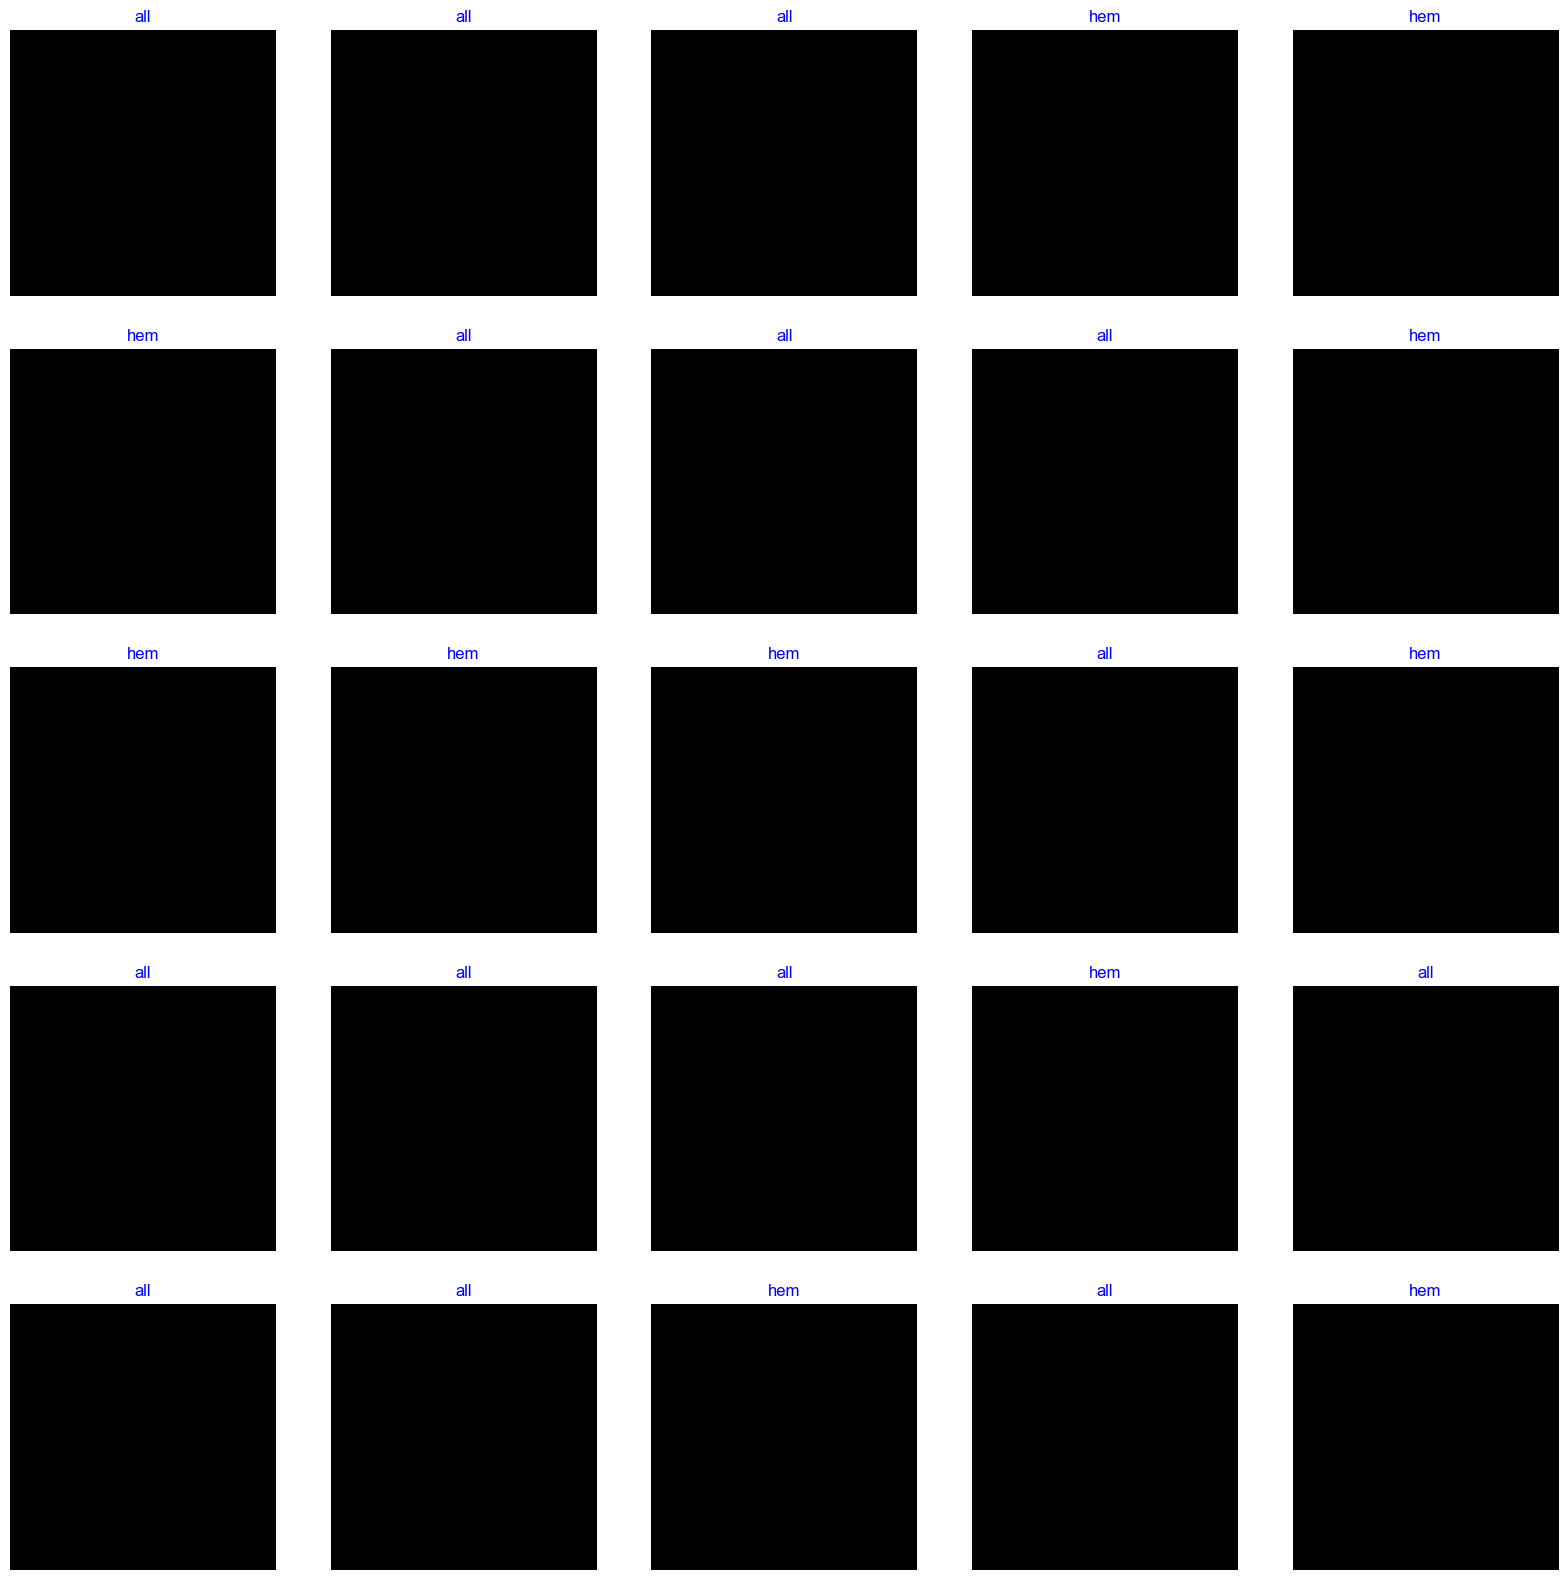

In [10]:
show_images(train_gen)


In [11]:
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

class_count = len(list(train_gen.class_indices.keys()))

base_model = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=img_shape,
    pooling='avg'
)
base_model.trainable = False

model = Sequential([
    base_model,
    BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    Dropout(rate=0.40, seed=123),
    Dense(class_count, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,304,514 (27.86 MB)

 Trainable params: 264,962 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [12]:
batch_size = 40
epochs = 40
patience = 1
stop_patience = 3
threshold = 0.9
factor = 0.5
ask_epoch = 5
batches = int(np.ceil(len(train_gen.labels) / batch_size))

callbacks = [MyCallback(patience= patience, stop_patience= stop_patience, threshold= threshold,
            factor= factor, batches= batches, epochs= epochs, ask_epoch= ask_epoch )]

In [ ]:
history = model.fit(x=train_gen, epochs=epochs, verbose=0, callbacks=callbacks,
                    validation_data=valid_gen, validation_steps=None, shuffle=False)


Do you want model asks you to halt the training [y/n] ?
 Epoch     Loss   Accuracy  V_loss    V_acc     LR     Next LR  Monitor  % Improv  Duration
 1 /40     0.587   74.816   0.50184  79.300   0.00010  0.00010  accuracy     0.00    206.59 
 2 /40     0.482   81.129   0.44196  83.365   0.00010  0.00010  accuracy     8.44    215.98 
 3 /40     0.447   82.683   0.40980  83.677   0.00010  0.00010  accuracy     1.92    209.46 
 4 /40     0.417   83.715   0.39559  84.240   0.00010  0.00010  accuracy     1.25    239.81 
 5 /40     0.399   84.184   0.38506  84.428   0.00010  0.00010  accuracy     0.56    252.16 
 6 /40     0.389   84.426   0.38057  85.053   0.00010  0.00010  accuracy     0.29    192.60 
 7 /40     0.383   85.109   0.37425  85.116   0.00010  0.00010  accuracy     0.81    222.47 
 8 /40     0.363   86.128   0.37018  84.991   0.00010  0.00010  accuracy     1.20    205.99 
 9 /40     0.351   86.342   0.36731  85.428   0.00010  0.00010  accuracy     0.25    246.88 
10 /40     0.34

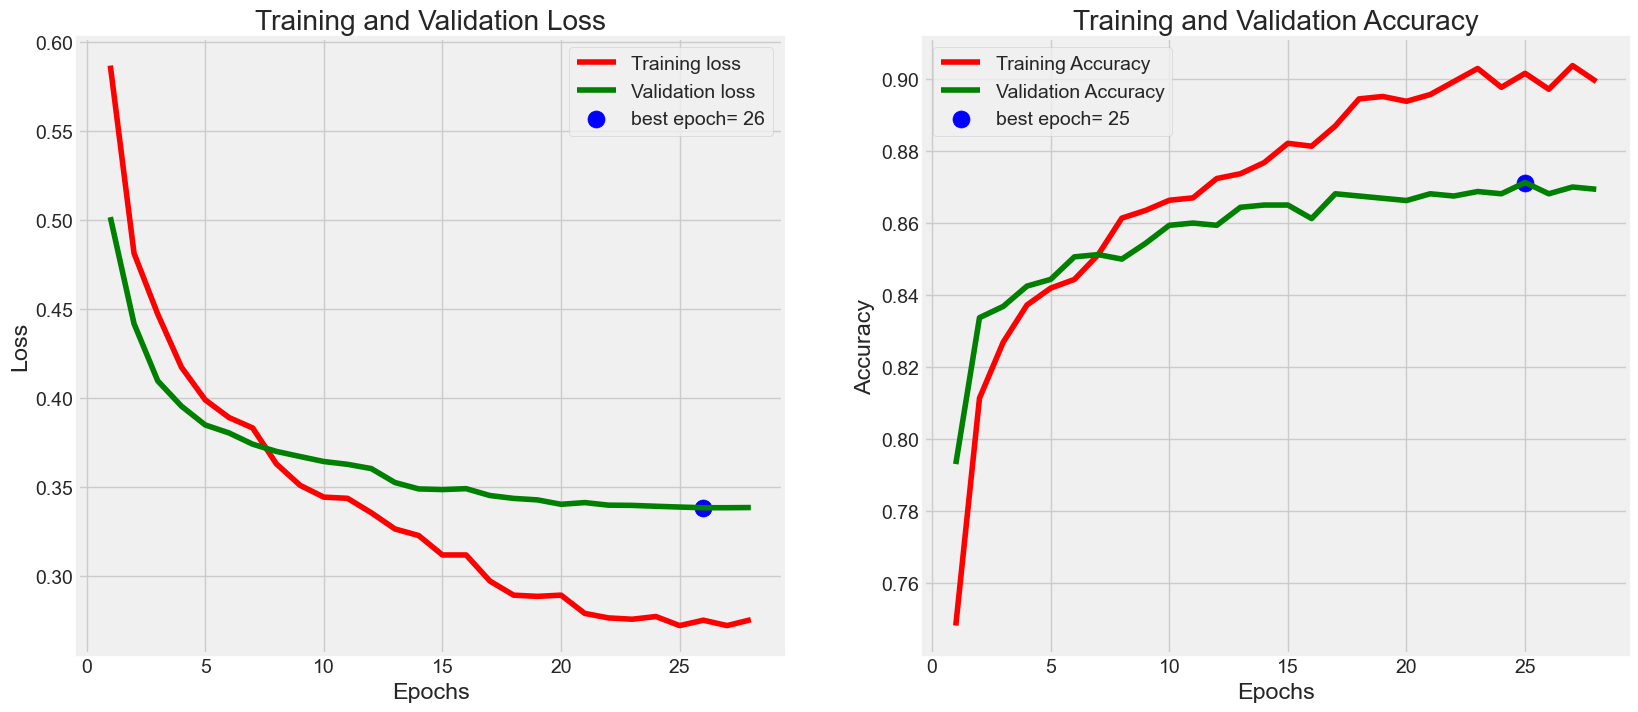

In [14]:
plot_training(history)

In [15]:
ts_length = len(test_df)
test_batch_size = test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9187 - loss: 0.2386
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 966ms/step - accuracy: 0.8637 - loss: 0.3519
20/20 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.8675 - loss: 0.3603
Train Loss:  0.23863133788108826
Train Accuracy:  0.918749988079071
--------------------
Validation Loss:  0.3519020974636078
Validation Accuracy:  0.8637499809265137
--------------------
Test Loss:  0.36033934354782104
Test Accuracy:  0.8675000071525574


In [16]:
preds = model.predict(test_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)
print(y_pred)


20/20 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step
[0 0 0 ... 0 1 0]


Confusion Matrix, Without Normalization
[[1033   58]
 [ 154  355]]
              precision    recall  f1-score   support

         all       0.87      0.95      0.91      1091
         hem       0.86      0.70      0.77       509

    accuracy                           0.87      1600
   macro avg       0.86      0.82      0.84      1600
weighted avg       0.87      0.87      0.86      1600



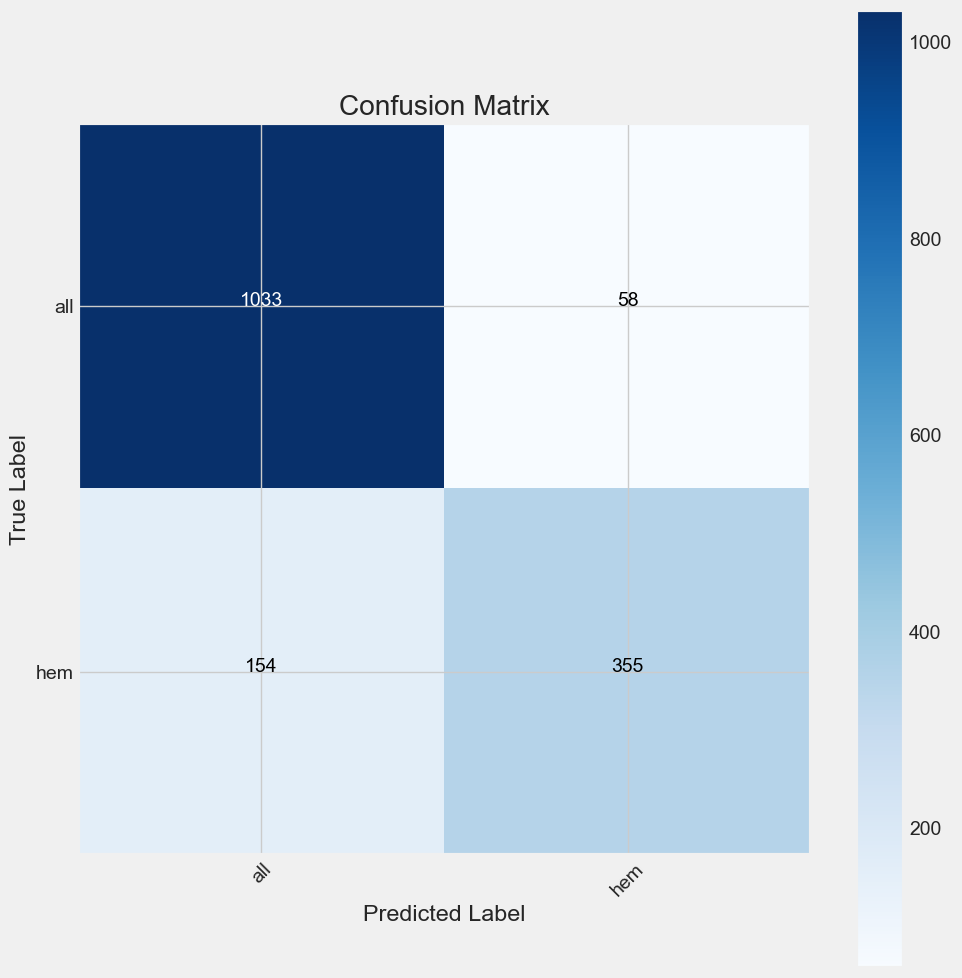

In [17]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

cm = confusion_matrix(test_gen.classes, y_pred)
plot_confusion_matrix(cm= cm, classes= classes, title = 'Confusion Matrix')

print(classification_report(test_gen.classes, y_pred, target_names= classes))

In [18]:
subject = input('Enter Project Subject (default: CNMC-DenseNet121): ').strip() or 'CNMC-DenseNet121'
acc = test_score[1] * 100
save_path = 'models'
os.makedirs(save_path, exist_ok=True)

deployment_model_name = 'densenet121-trained.keras'
deployment_model_loc = os.path.join(save_path, deployment_model_name)
model.save(deployment_model_loc)
print(f'deployment model was saved as {deployment_model_loc}')

versioned_save_id = f'densenet121-{subject}-{acc:.2f}.keras'
versioned_model_loc = os.path.join(save_path, versioned_save_id)
if versioned_model_loc != deployment_model_loc:
    model.save(versioned_model_loc)
    print(f'versioned model was saved as {versioned_model_loc}')

weight_save_id = f'densenet121-{subject}-weights.h5'
weights_save_loc = os.path.join(save_path, weight_save_id)
model.save_weights(weights_save_loc)
print(f'weights were saved as {weights_save_loc}')


deployment model was saved as models/densenet121-trained.keras
versioned model was saved as models/densenet121-aryan-86.75.keras


ValueError: The filename must end in `.weights.h5`. Received: filepath=models/densenet121-aryan-weights.h5

In [19]:
class_dict = train_gen.class_indices
img_size = train_gen.image_shape
height = []
width = []
for _ in range(len(class_dict)):
    height.append(img_size[0])
    width.append(img_size[1])

Index_series = pd.Series(list(class_dict.values()), name= 'class_index')
Class_series = pd.Series(list(class_dict.keys()), name= 'class')
Height_series = pd.Series(height, name= 'height')
Width_series = pd.Series(width, name= 'width')
class_df = pd.concat([Index_series, Class_series, Height_series, Width_series], axis= 1)
csv_name = f'{subject}-class_dict.csv'
csv_save_loc = os.path.join(save_path, csv_name)
class_df.to_csv(csv_save_loc, index= False)
print(f'class csv file was saved as {csv_save_loc}')

class csv file was saved as models/aryan-class_dict.csv
